In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math
import cc3d
from scipy import stats

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

In [2]:
t=3

source_input_dir = Path("/mnt/stor-pool-01/projects/heus/BNF/Ensemble_Tests/512_512_50m_12km_chbuff/2025-07-01_normal_shell/thijs")
input_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS")
ds_e = xr.open_dataset(source_input_dir / "netE.nc", decode_times=False)
ds_ql = xr.open_dataset(source_input_dir / "ql.nc", decode_times=False)
ds_shell_mask = xr.open_dataset(input_dir / "shell_mask.nc", decode_times=False)
ds_cloud_mask = xr.open_dataset(input_dir / "cloud_mask.nc", decode_times=False)


In [3]:

t_size = len(ds_cloud_mask.time.values)

expansion = np.zeros((3,3,3), dtype=bool)
expansion[1, 1, :] = True  # X axis
expansion[1, :, 1] = True  # Y axis
expansion[:, 1, 1] = True  # Z axis

target_time = 150e3

closest_time_ds = ds_cloud_mask.sel(time=target_time, method="nearest")

time_index = int(np.where(ds_cloud_mask.time == closest_time_ds.time)[0][0])

for t_idx in [time_index]:
    shell_mask_slice = ds_shell_mask.isel(time=t_idx)
    cloud_mask_slice = ds_cloud_mask.isel(time=t_idx)

    shell_mask = (shell_mask_slice.shell_mask != 0)
    cloud_mask = (cloud_mask_slice.cloud_mask != 0)

    is_cloud = bool(np.any(cloud_mask))
    is_shell = bool(np.any(shell_mask))

    if((not is_cloud) and (not is_shell)):
        print(f"(Timestep {t_idx + 1}/{t_size}): Neither a cloud or shell exists")
        continue
    elif not is_cloud:
        print(f"(Timestep {t_idx + 1}/{t_size}): Cloud does not exist")
        continue
    elif not is_shell:
        print(f"(Timestep {t_idx + 1}/{t_size}): Shell does not exist")
        continue

    ql_dilation = 1

    cloud_bool = cloud_mask.values.astype(bool)
    shell_bool = shell_mask.values.astype(bool)

    dilated_cloud = cloud_bool.copy()
    for _ in range(ql_dilation):
        padded = np.pad(dilated_cloud, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
        padded = np.pad(padded, ((0, 0), (1, 1), (1, 1)), mode='wrap')
        padded_dilated = scipy.ndimage.binary_dilation(padded, structure=expansion)
        dilated_cloud = padded_dilated[1:-1, 1:-1, 1:-1]

    padded_shell = np.pad(shell_bool, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
    padded_shell = np.pad(padded_shell, ((0, 0), (1, 1), (1, 1)), mode='wrap')
    padded_dilated_shell = scipy.ndimage.binary_dilation(padded_shell, structure=expansion)
    dilated_shell = padded_dilated_shell[1:-1, 1:-1, 1:-1]

    clear_space = ~(cloud_bool | shell_bool)

    gap = clear_space & dilated_cloud & dilated_shell

    gap_mask = xr.DataArray(gap, coords=cloud_mask.coords, dims=cloud_mask.dims)

    
    is_gap = bool(np.any(gap))

    if is_gap:
        print(f"(Timestep {t_idx + 1}/{t_size}): GAP EXISTS")
    else:
        print(f"(Timestep {t_idx + 1}/{t_size}): Gap does not exist")



(Timestep 41/160): GAP EXISTS


In [4]:
# 1. Get the spatial coordinate indices
z_idx, y_idx, x_idx = np.where(gap_mask.values == 1)

# 2. Map indices back to physical dimensions
gap_z_coords = gap_mask.z.values[z_idx]
gap_y_coords = gap_mask.y.values[y_idx]
gap_x_coords = gap_mask.x.values[x_idx]

In [5]:
z_indices = np.where(gap_mask.values == 1)[0]

most_common_z_index = 0
if len(z_indices) > 0:
    # 2. Compute the mode on the index array directly
    mode_result = stats.mode(z_indices, keepdims=True)
    
    most_common_z_index = mode_result.mode[0]
    count = mode_result.count[0]
    
    print(f"The most common Z grid index is: {most_common_z_index} (occurs {count} times)")

The most common Z grid index is: 47 (occurs 1656 times)


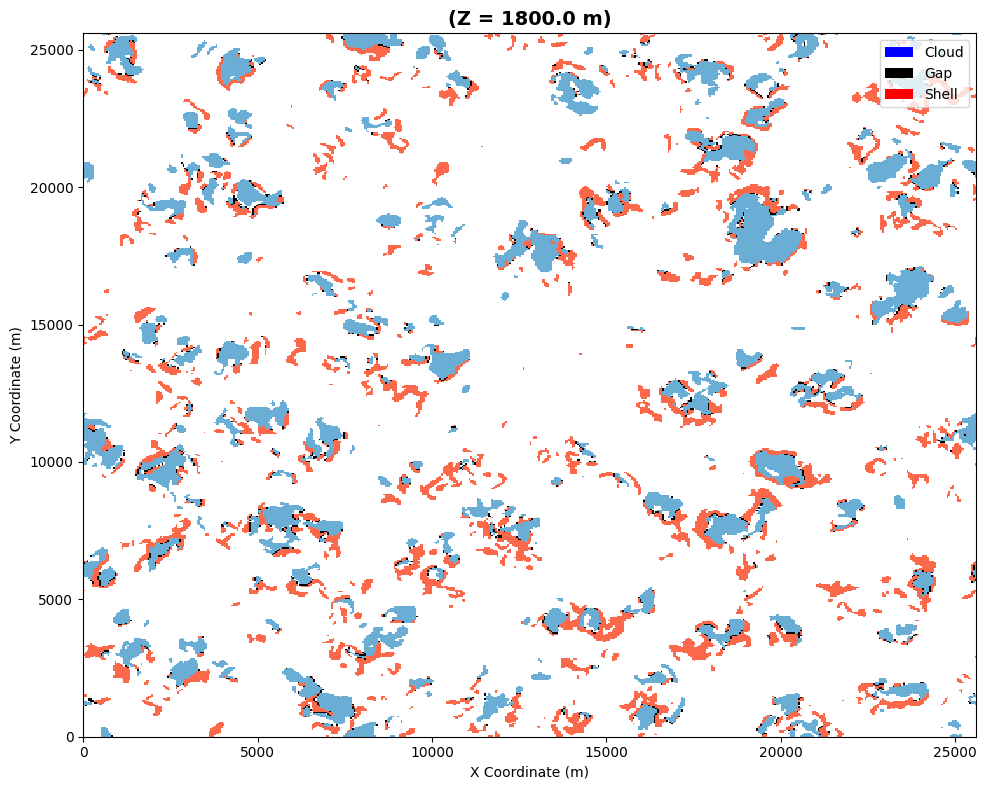

In [8]:
#Plotting for most gaps
# 1. Isolate the 2D horizontal slices at your most common Z index
# (Using .isel to slice via the grid index number)
z_target = most_common_z_index
#z_target = 44

shell_2d = shell_mask.isel(z=z_target)
cloud_2d = cloud_mask.isel(z=z_target)
gap_2d = gap_mask.isel(z=z_target)

# 2. Initialize your plot figure
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Layer the masks using .where() to make 0-values transparent
# We use custom single-color colormaps ('Reds', 'Blues', 'Greys')

# Layer 1: Cloud Mask in Blue
cloud_2d.where(cloud_2d == 1).plot(
    ax=ax, cmap="Blues", add_colorbar=False, alpha=1
)

# Layer 2: Shell Mask in Red
shell_2d.where(shell_2d == 1).plot(
    ax=ax, cmap="Reds", add_colorbar=False, alpha=1
)

black_cmap = ListedColormap(['#000000'])

# Layer 3: Gap Mask in Black (using the 'Greys' colormap)
gap_2d.where(gap_2d == 1).plot(
    ax=ax, cmap=black_cmap, add_colorbar=False, alpha=1
)

# 4. Clean up labels and title
physical_height = gap_mask.z.values[z_target]
ax.set_title(f"(Z = {physical_height:.1f} m)", fontsize=14, fontweight='bold')
ax.set_xlabel("X Coordinate (m)")
ax.set_ylabel("Y Coordinate (m)")

# Add a manual legend since they are binary masks
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Cloud'),
    Patch(facecolor='black', label='Gap'),
    Patch(facecolor='red', label='Shell')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
"""
for i in range(len(gap_z_coords)):
    gap_i_z = gap_z_coords[i]
    gap_i_y = gap_y_coords[i]
    gap_i_x = gap_x_coords[i]
    print(f"Gap {i+1}/{len(gap_z_coords)} at z={gap_i_z}, y={gap_i_y}, x={gap_i_x}")
"""

'\nfor i in range(len(gap_z_coords)):\n    gap_i_z = gap_z_coords[i]\n    gap_i_y = gap_y_coords[i]\n    gap_i_x = gap_x_coords[i]\n    print(f"Gap {i+1}/{len(gap_z_coords)} at z={gap_i_z}, y={gap_i_y}, x={gap_i_x}")\n'

In [8]:

t_size = len(ds_cloud_mask.time.values)

expansion = np.zeros((3,3,3), dtype=bool)
expansion[1, 1, :] = True  # X axis
expansion[1, :, 1] = True  # Y axis
expansion[:, 1, 1] = True  # Z axis

i=1
s=323

for t_idx in range(t_size):
    i += 2
    shell_mask_slice = ds_shell_mask.isel(time=t_idx)
    cloud_mask_slice = ds_cloud_mask.isel(time=t_idx)

    shell_mask = (shell_mask_slice.shell_mask != 0)
    cloud_mask = (cloud_mask_slice.cloud_mask != 0)

    is_cloud = bool(np.any(cloud_mask))
    is_shell = bool(np.any(shell_mask))

    if((not is_cloud) and (not is_shell)):
        print(f"(Timestep {i}/{s}): Neither a cloud or shell exists")
        continue
    elif not is_cloud:
        print(f"(Timestep {i}/{s}): Cloud does not exist")
        continue
    elif not is_shell:
        print(f"(Timestep {i}/{s}): Shell does not exist")
        continue

    ql_dilation = 1

    cloud_bool = cloud_mask.values.astype(bool)
    shell_bool = shell_mask.values.astype(bool)

    dilated_cloud = cloud_bool.copy()
    for _ in range(ql_dilation):
        padded = np.pad(dilated_cloud, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
        padded = np.pad(padded, ((0, 0), (1, 1), (1, 1)), mode='wrap')
        padded_dilated = scipy.ndimage.binary_dilation(padded, structure=expansion)
        dilated_cloud = padded_dilated[1:-1, 1:-1, 1:-1]

    padded_shell = np.pad(shell_bool, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
    padded_shell = np.pad(padded_shell, ((0, 0), (1, 1), (1, 1)), mode='wrap')
    padded_dilated_shell = scipy.ndimage.binary_dilation(padded_shell, structure=expansion)
    dilated_shell = padded_dilated_shell[1:-1, 1:-1, 1:-1]

    clear_space = ~(cloud_bool | shell_bool)

    gap = clear_space & dilated_cloud & dilated_shell

    gap_mask = xr.DataArray(gap, coords=cloud_mask.coords, dims=cloud_mask.dims)
    
    
    z_indices = np.where(gap_mask.values == 1)[0]
    
    is_gap = len(z_indices) > 0

    if is_gap:
        print(f"(Timestep {i}/{s}): GAP EXISTS (Count: {len(z_indices)})")
    else:
        print(f"(Timestep {i}/{s}): Gap does not exist")



(Timestep 3/323): Neither a cloud or shell exists
(Timestep 5/323): Neither a cloud or shell exists
(Timestep 7/323): Neither a cloud or shell exists
(Timestep 9/323): Shell does not exist
(Timestep 11/323): GAP EXISTS (Count: 31725)
(Timestep 13/323): GAP EXISTS (Count: 8121)
(Timestep 15/323): GAP EXISTS (Count: 135)
(Timestep 17/323): Neither a cloud or shell exists
(Timestep 19/323): Neither a cloud or shell exists
(Timestep 21/323): Neither a cloud or shell exists
(Timestep 23/323): Neither a cloud or shell exists
(Timestep 25/323): GAP EXISTS (Count: 2243)
(Timestep 27/323): GAP EXISTS (Count: 7200)
(Timestep 29/323): GAP EXISTS (Count: 44205)
(Timestep 31/323): GAP EXISTS (Count: 65274)
(Timestep 33/323): GAP EXISTS (Count: 79936)
(Timestep 35/323): GAP EXISTS (Count: 63089)
(Timestep 37/323): GAP EXISTS (Count: 72037)
(Timestep 39/323): GAP EXISTS (Count: 31399)
(Timestep 41/323): GAP EXISTS (Count: 95769)
(Timestep 43/323): GAP EXISTS (Count: 84194)
(Timestep 45/323): GAP EXIS